In [18]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib import pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import itertools

# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

def prepare_time_series(df, value_name='flow'):
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]

    # Convert to numeric and fill missing
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')

    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.dropna(subset=['date'])
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    # Ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)
    
    return ts


def prepare_ml_data(ts, window_size=12, split_date='2014-01-01'):
    
    ts = ts.copy()
    ts['flow'] = ts['flow'].clip(lower=0)

    # Seasonal encoding
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # Log transform
    y_log = np.log1p(y)

    # Train/test split
    split_date = pd.to_datetime(split_date)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],        # original scale
        "idx_test": idx[split:]
    }

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return 0
    return 1 - np.sum((y_true - y_pred)**2) / denom

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return rmse, mae, nse

In [19]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

def tune_nn(X_train, y_train):

    param_grid = {
        'hidden_layer_sizes': [(64,), (128, ), (32, )],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }

    tscv = TimeSeriesSplit(n_splits=5)

    best_score = -np.inf
    best_params = None
    best_scaler = None

    for hl, alpha, lr in itertools.product(
        param_grid['hidden_layer_sizes'],
        param_grid['alpha'],
        param_grid['learning_rate_init']
    ):

        scores = []

        for train_idx, val_idx in tscv.split(X_train):

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # 🔥 SCALE INPUTS (critical for NN)
            scaler = StandardScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_val_scaled = scaler.transform(X_val)

            model = MLPRegressor(
                hidden_layer_sizes=hl,
                alpha=alpha,
                learning_rate_init=lr,
                max_iter=5000,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            )

            model.fit(X_tr_scaled, y_tr)

            # Predict
            y_pred = np.expm1(model.predict(X_val_scaled))
            y_true = np.expm1(y_val)

            score = nse(y_true, y_pred)
            scores.append(score)

        avg_score = np.mean(scores)

        if avg_score > best_score:
            best_score = avg_score
            best_params = (hl, alpha, lr)

    print("\nBest NN params (CV NSE):", best_score)
    print("Params:", best_params)

    # ✅ FINAL MODEL
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    best_model = MLPRegressor(
        hidden_layer_sizes=best_params[0],
        alpha=best_params[1],
        learning_rate_init=best_params[2],
        max_iter=5000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )

    best_model.fit(X_train_scaled, y_train)

    return best_model, scaler

In [20]:
def test_nn_with_config(model, scaler, data):

    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # Scale
    X_test_scaled = scaler.transform(X_test)

    # Predict
    y_pred = np.expm1(model.predict(X_test_scaled))

    # Safety (no negative flows)
    y_pred = np.maximum(y_pred, 0)

    # Align
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # Metrics
    rmse, mae, nse_val = compute_metrics(y_test, y_pred)

    print("\n==============================")
    print(f"Neural Network (MLP)")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_test, label='Actual')
    plt.plot(idx, y_pred, label='NN', marker='x')
    plt.title("Neural Network Prediction (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred


Best NN params (CV NSE): -0.16687517868984192
Params: ((128,), 0.01, 0.001)

Neural Network (MLP)
RMSE: 100.50
MAE : 66.63
NSE : -7.3052


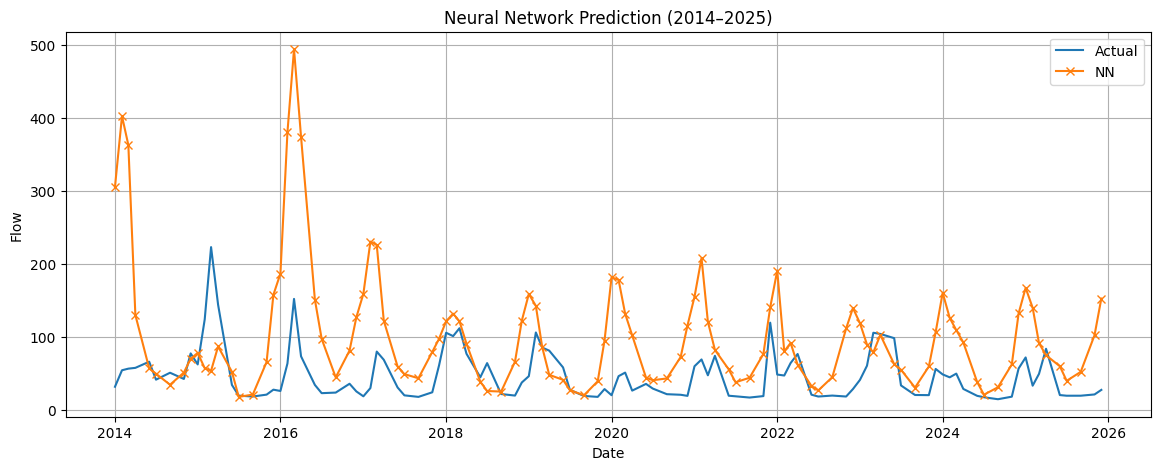

In [21]:
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

ts_qmin = prepare_time_series(q_min)
data = prepare_ml_data(ts_qmin)

## train-test split 
X_train = data["X_train"]
y_train = data["y_train"]

X_test  = data["X_test"]
y_test  = data["y_test"]
idx     = data["idx_test"]


nn_model, nn_scaler = tune_nn(X_train, y_train)
y_pred_nn = test_nn_with_config(nn_model, nn_scaler, data)